In [39]:
#import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import pandas_datareader.data as web
import datetime

In [40]:
#functions

##Black Shcholes model
# c = s * N(d1) - e * np.exp(-r*t) * N(d2)
def c(s,e,rf,d1,d2,t):
    rf = np.exp(-rf*t)
    n_d1 = norm.cdf(d1)
    n_d2 = norm.cdf(d2)
    c = (s * n_d1) - (e * rf * n_d2)
    return c

# Calculating d1 and d2 Using the Black-Scholes Model
def d(s, e, r, sig, t):
    d1 = (np.log(s/e) + (r + (sig**2)/2)*t) / (sig * np.sqrt(t)) 
    d2 = d1 - (sig * np.sqrt(t))
    return d1, d2

#put call perity for put option
def put_perity(e,r,c,s,t):
    r = np.exp(-r*t)
    p = e*r+c-s
    return p

In [41]:
#install stock's data
ticker = "AAPL"

df = yf.download(tickers = ticker, start = "2025-01-01", end = "2025-12-31", group_by= "columns")

s = df[ticker]["Close"]["2025-01-02"]
s


[*********************100%***********************]  1 of 1 completed


np.float64(242.3019256591797)

In [42]:
# rf data
start = datetime.datetime(2025, 1, 1)
end = datetime.datetime(2025, 12, 31)

rf_rate = web.DataReader("DGS1", "fred", start, end)
rf_rate = rf_rate / 100   # FRED는 %(예: 4.5)로 주니까 소수로 변환

r = rf_rate["DGS1"]["2025-01-02"]
r

np.float64(0.0417)

In [43]:
#sigma
returns = np.log(df["AAPL"]["Close"]/df["AAPL"]["Close"].shift(1)).dropna()
daily_vol = returns.std()
annual_vol = daily_vol * np.sqrt(252)

sig = annual_vol # T is 1year


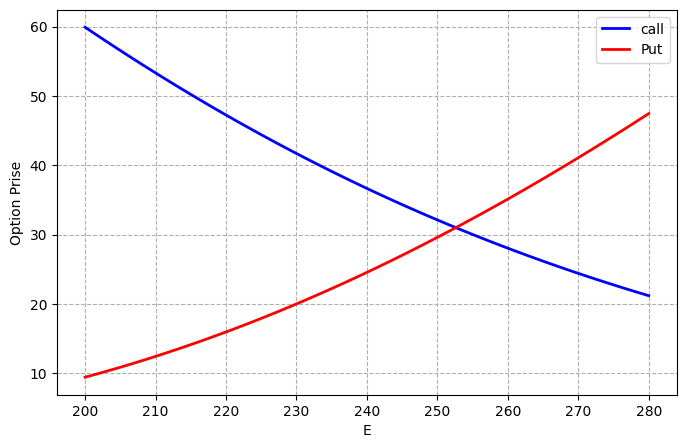

In [ ]:
t = 1
e = np.linspace(200,280,101)

d1 = d(s,e,r,sig,t)[0]
d2 = d(s,e,r,sig,t)[1]

call = c(s,e,r,d1,d2,t)
put = put_perity(e,r,call,s,t)



fig, ax = plt.subplots(figsize=(8,5))
ax.plot(e, call, color = 'blue', linewidth = 2, label = "call")
ax.plot(e, put, color = "red", linewidth = 2, label = "Put")
plt.xlabel("E")
plt.ylabel("Option Prise")
plt.legend()
plt.grid(linestyle = "--")
plt.show()

